# Insights do cruzamento (PAM x PPM x PIB)

Explora correlações no dataset já integrado (`dados/analytical/cruzamento_pam_ppm_pib.csv`), grão município + ano. Mesma regra de sempre: produtos da PAM e espécies da PPM nunca são somados entre si — as correlações abaixo são sempre entre colunas individuais, nunca entre somas artificiais.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
df = pd.read_csv('../dados/analytical/cruzamento_pam_ppm_pib.csv')
df.head()

,territorio_codigo,territorio_nome,ano_nome,pam_area_colhida_banana,pam_area_colhida_cana,pam_area_colhida_castanha_caju,pam_area_colhida_feijao,pam_area_colhida_mandioca,pam_area_colhida_melao,pam_area_colhida_milho,pam_area_plantada_banana,pam_area_plantada_cana,pam_area_plantada_castanha_caju,pam_area_plantada_feijao,pam_area_plantada_mandioca,pam_area_plantada_melao,pam_area_plantada_milho,pam_quantidade_banana,pam_quantidade_cana,pam_quantidade_castanha_caju,pam_quantidade_feijao,pam_quantidade_mandioca,pam_quantidade_melao,pam_quantidade_milho,pam_rendimento_banana,pam_rendimento_cana,pam_rendimento_castanha_caju,pam_rendimento_feijao,pam_rendimento_mandioca,pam_rendimento_melao,pam_rendimento_milho,pam_valor_banana,pam_valor_cana,pam_valor_castanha_caju,pam_valor_feijao,pam_valor_mandioca,pam_valor_melao,pam_valor_milho,ppm_efetivo_bovino,ppm_efetivo_caprino,ppm_efetivo_galinaceos,ppm_efetivo_ovino,ppm_efetivo_suino,pib_pct_agropecuario_vab,pib_pib,pib_vab_agropecuario,pib_vab_total
0,2300101,Abaiara - CE,2003,26.0,100.0,10.0,1300.0,8.0,0.0,2800.0,26.0,100.0,10.0,1300.0,8.0,0.0,2800.0,176.0,5500.0,4.0,702.0,83.0,0.0,5236.0,6769.0,55000.0,400.0,540.0,10375.0,0.0,1870.0,56.0,192.0,4.0,917.0,18.0,0.0,1906.0,5311.0,280.0,25403.0,278.0,539.0,34.46,17657.0,5897.0,17110.0
1,2300101,Abaiara - CE,2004,26.0,80.0,10.0,1333.0,8.0,0.0,2660.0,26.0,80.0,10.0,1520.0,8.0,0.0,2660.0,169.0,4000.0,5.0,445.0,84.0,0.0,2934.0,6500.0,50000.0,500.0,333.0,10500.0,0.0,1103.0,62.0,152.0,6.0,398.0,16.0,0.0,1141.0,5433.0,290.0,26484.0,285.0,555.0,26.28,16808.0,4235.0,16118.0
2,2300101,Abaiara - CE,2005,27.0,80.0,10.0,532.0,11.0,0.0,1158.0,27.0,80.0,10.0,532.0,11.0,0.0,1158.0,184.0,3360.0,4.0,117.0,132.0,0.0,903.0,6814.0,42000.0,400.0,219.0,12000.0,0.0,779.0,76.0,119.0,4.0,176.0,12.0,0.0,302.0,5615.0,303.0,27762.0,295.0,574.0,18.69,17153.0,3059.0,16367.0
3,2300101,Abaiara - CE,2006,35.0,60.0,10.0,750.0,11.0,0.0,1440.0,35.0,60.0,10.0,750.0,11.0,0.0,1440.0,525.0,2400.0,3.0,450.0,132.0,0.0,2880.0,15000.0,40000.0,300.0,600.0,12000.0,0.0,2000.0,297.0,97.0,3.0,401.0,11.0,0.0,877.0,5790.0,318.0,28866.0,303.0,587.0,23.04,22869.0,5060.0,21960.0
4,2300101,Abaiara - CE,2007,35.0,42.0,10.0,1520.0,11.0,0.0,3810.0,35.0,42.0,10.0,1520.0,11.0,0.0,3810.0,415.0,1400.0,3.0,353.0,117.0,0.0,3225.0,11857.0,33333.0,300.0,232.0,10636.0,0.0,846.0,231.0,58.0,2.0,418.0,21.0,0.0,1329.0,5969.0,333.0,30095.0,310.0,600.0,19.74,25383.0,4831.0,24475.0


Como é o dataset cruzado bruto?

In [3]:
colunas_codigo = [c for c in df.columns if c.endswith('_codigo')]
df_nome = df.drop(columns=colunas_codigo)
df_nome.head()

,territorio_nome,ano_nome,pam_area_colhida_banana,pam_area_colhida_cana,pam_area_colhida_castanha_caju,pam_area_colhida_feijao,pam_area_colhida_mandioca,pam_area_colhida_melao,pam_area_colhida_milho,pam_area_plantada_banana,pam_area_plantada_cana,pam_area_plantada_castanha_caju,pam_area_plantada_feijao,pam_area_plantada_mandioca,pam_area_plantada_melao,pam_area_plantada_milho,pam_quantidade_banana,pam_quantidade_cana,pam_quantidade_castanha_caju,pam_quantidade_feijao,pam_quantidade_mandioca,pam_quantidade_melao,pam_quantidade_milho,pam_rendimento_banana,pam_rendimento_cana,pam_rendimento_castanha_caju,pam_rendimento_feijao,pam_rendimento_mandioca,pam_rendimento_melao,pam_rendimento_milho,pam_valor_banana,pam_valor_cana,pam_valor_castanha_caju,pam_valor_feijao,pam_valor_mandioca,pam_valor_melao,pam_valor_milho,ppm_efetivo_bovino,ppm_efetivo_caprino,ppm_efetivo_galinaceos,ppm_efetivo_ovino,ppm_efetivo_suino,pib_pct_agropecuario_vab,pib_pib,pib_vab_agropecuario,pib_vab_total
0,Abaiara - CE,2003,26.0,100.0,10.0,1300.0,8.0,0.0,2800.0,26.0,100.0,10.0,1300.0,8.0,0.0,2800.0,176.0,5500.0,4.0,702.0,83.0,0.0,5236.0,6769.0,55000.0,400.0,540.0,10375.0,0.0,1870.0,56.0,192.0,4.0,917.0,18.0,0.0,1906.0,5311.0,280.0,25403.0,278.0,539.0,34.46,17657.0,5897.0,17110.0
1,Abaiara - CE,2004,26.0,80.0,10.0,1333.0,8.0,0.0,2660.0,26.0,80.0,10.0,1520.0,8.0,0.0,2660.0,169.0,4000.0,5.0,445.0,84.0,0.0,2934.0,6500.0,50000.0,500.0,333.0,10500.0,0.0,1103.0,62.0,152.0,6.0,398.0,16.0,0.0,1141.0,5433.0,290.0,26484.0,285.0,555.0,26.28,16808.0,4235.0,16118.0
2,Abaiara - CE,2005,27.0,80.0,10.0,532.0,11.0,0.0,1158.0,27.0,80.0,10.0,532.0,11.0,0.0,1158.0,184.0,3360.0,4.0,117.0,132.0,0.0,903.0,6814.0,42000.0,400.0,219.0,12000.0,0.0,779.0,76.0,119.0,4.0,176.0,12.0,0.0,302.0,5615.0,303.0,27762.0,295.0,574.0,18.69,17153.0,3059.0,16367.0
3,Abaiara - CE,2006,35.0,60.0,10.0,750.0,11.0,0.0,1440.0,35.0,60.0,10.0,750.0,11.0,0.0,1440.0,525.0,2400.0,3.0,450.0,132.0,0.0,2880.0,15000.0,40000.0,300.0,600.0,12000.0,0.0,2000.0,297.0,97.0,3.0,401.0,11.0,0.0,877.0,5790.0,318.0,28866.0,303.0,587.0,23.04,22869.0,5060.0,21960.0
4,Abaiara - CE,2007,35.0,42.0,10.0,1520.0,11.0,0.0,3810.0,35.0,42.0,10.0,1520.0,11.0,0.0,3810.0,415.0,1400.0,3.0,353.0,117.0,0.0,3225.0,11857.0,33333.0,300.0,232.0,10636.0,0.0,846.0,231.0,58.0,2.0,418.0,21.0,0.0,1329.0,5969.0,333.0,30095.0,310.0,600.0,19.74,25383.0,4831.0,24475.0


Como fica sem as colunas de código?

In [4]:
print(f"Linhas: {len(df_nome)} · Colunas: {len(df_nome.columns)}")
df_nome.describe()

Linhas: 4048 · Colunas: 46


,ano_nome,pam_area_colhida_banana,pam_area_colhida_cana,pam_area_colhida_castanha_caju,pam_area_colhida_feijao,pam_area_colhida_mandioca,pam_area_colhida_melao,pam_area_colhida_milho,pam_area_plantada_banana,pam_area_plantada_cana,pam_area_plantada_castanha_caju,pam_area_plantada_feijao,pam_area_plantada_mandioca,pam_area_plantada_melao,pam_area_plantada_milho,pam_quantidade_banana,pam_quantidade_cana,pam_quantidade_castanha_caju,pam_quantidade_feijao,pam_quantidade_mandioca,pam_quantidade_melao,pam_quantidade_milho,pam_rendimento_banana,pam_rendimento_cana,pam_rendimento_castanha_caju,pam_rendimento_feijao,pam_rendimento_mandioca,pam_rendimento_melao,pam_rendimento_milho,pam_valor_banana,pam_valor_cana,pam_valor_castanha_caju,pam_valor_feijao,pam_valor_mandioca,pam_valor_melao,pam_valor_milho,ppm_efetivo_bovino,ppm_efetivo_caprino,ppm_efetivo_galinaceos,ppm_efetivo_ovino,ppm_efetivo_suino,pib_pct_agropecuario_vab,pib_pib,pib_vab_agropecuario,pib_vab_total
count,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4048.000000,4.048000e+03,4048.000000,4048.000000,3496.000000,3.864000e+03,3496.000000,3.496000e+03
mean,2013.500000,225.438488,136.922184,1876.865119,2472.091650,413.539032,24.772233,3134.333992,225.867342,137.492095,1881.486166,2490.106966,414.225543,24.772727,3159.563488,2207.148715,7243.387352,422.008893,689.991107,3522.708745,670.512846,2309.091897,9866.458498,27136.809536,232.059783,285.382905,8226.591403,1165.833992,693.434783,1875.680336,550.634881,949.651927,1552.931077,1114.068429,567.748518,1556.805336,13637.846097,5723.294219,1.544495e+05,11958.795949,6404.016057,16.875569,6.161391e+05,27779.116705,4.835493e+05
std,6.345073,626.656274,517.331619,4583.630281,2609.801569,1020.357251,205.263252,3600.777759,628.250952,517.559693,4587.711811,2634.617491,1020.935931,205.263202,3618.919260,6159.859512,29188.017627,1205.586219,917.049399,9567.344969,5554.577665,3921.131296,6979.574281,22109.747885,162.413271,162.527215,4680.637704,5392.933798,590.150715,6661.972707,2537.445633,3592.954452,2055.351537,3783.613596,4695.080819,2859.971883,13640.168400,8761.928875,3.926398e+05,18140.314645,6700.225625,9.747850,3.940754e+06,34733.029946,3.059432e+06
min,2003.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,149.000000,45.000000,1.945000e+03,0.000000,83.000000,0.070000,9.609000e+03,1313.000000,9.390000e+03
25%,2008.000000,5.000000,0.000000,11.000000,822.500000,8.000000,0.000000,950.000000,5.000000,0.000000,12.000000,830.000000,8.000000,0.000000,975.250000,37.750000,0.000000,3.000000,176.750000,66.000000,0.000000,356.000000,5400.000000,0.000000,100.000000,162.750000,5500.000000,0.000000,290.000000,29.000000,0.000000,5.000000,407.750000,24.000000,0.000000,218.000000,4635.750000,1168.000000,2.553450e+04,1975.750000,2596.000000,10.020000,6.263325e+04,8352.500000,5.608300e+04
50%,2013.500000,20.000000,6.000000,110.000000,1688.000000,40.000000,0.000000,2005.500000,20.000000,6.000000,111.000000,1700.000000,40.000000,0.000000,2031.500000,186.500000,226.500000,21.000000,405.000000,344.000000,0.000000,1018.000000,7883.000000,32000.000000,222.000000,254.000000,8500.000000,0.000000,550.000000,131.000000,19.000000,35.000000,889.500000,135.000000,0.000000,641.000000,9135.500000,2986.000000,4.601500e+04,5442.500000,4438.000000,15.150000,1.282645e+05,16989.000000,1.105370e+05
75%,2019.

Como se distribuem as colunas numéricas do cruzamento?

O cruzamento tem valores ausentes? Onde exatamente?

In [5]:
colunas_valor_check = [c for c in df_nome.columns if c not in ('territorio_codigo', 'territorio_nome', 'ano_nome')]
ausencia = (df_nome[colunas_valor_check].isna().mean() * 100).sort_values(ascending=False)

print("Linhas duplicadas:", df_nome.duplicated().sum())
print()
print("% de ausência por coluna (só as com algum valor faltando):")
print(ausencia[ausencia > 0])

Linhas duplicadas: 0

% de ausência por coluna (só as com algum valor faltando):
pib_vab_agropecuario        13.636364
pib_vab_total               13.636364
pib_pct_agropecuario_vab    13.636364
pib_pib                      4.545455
dtype: float64


## Correlação entre todas as variáveis

Existe alguma correlação entre as variáveis do PAM, PPM e PIB, olhando tudo de uma vez?

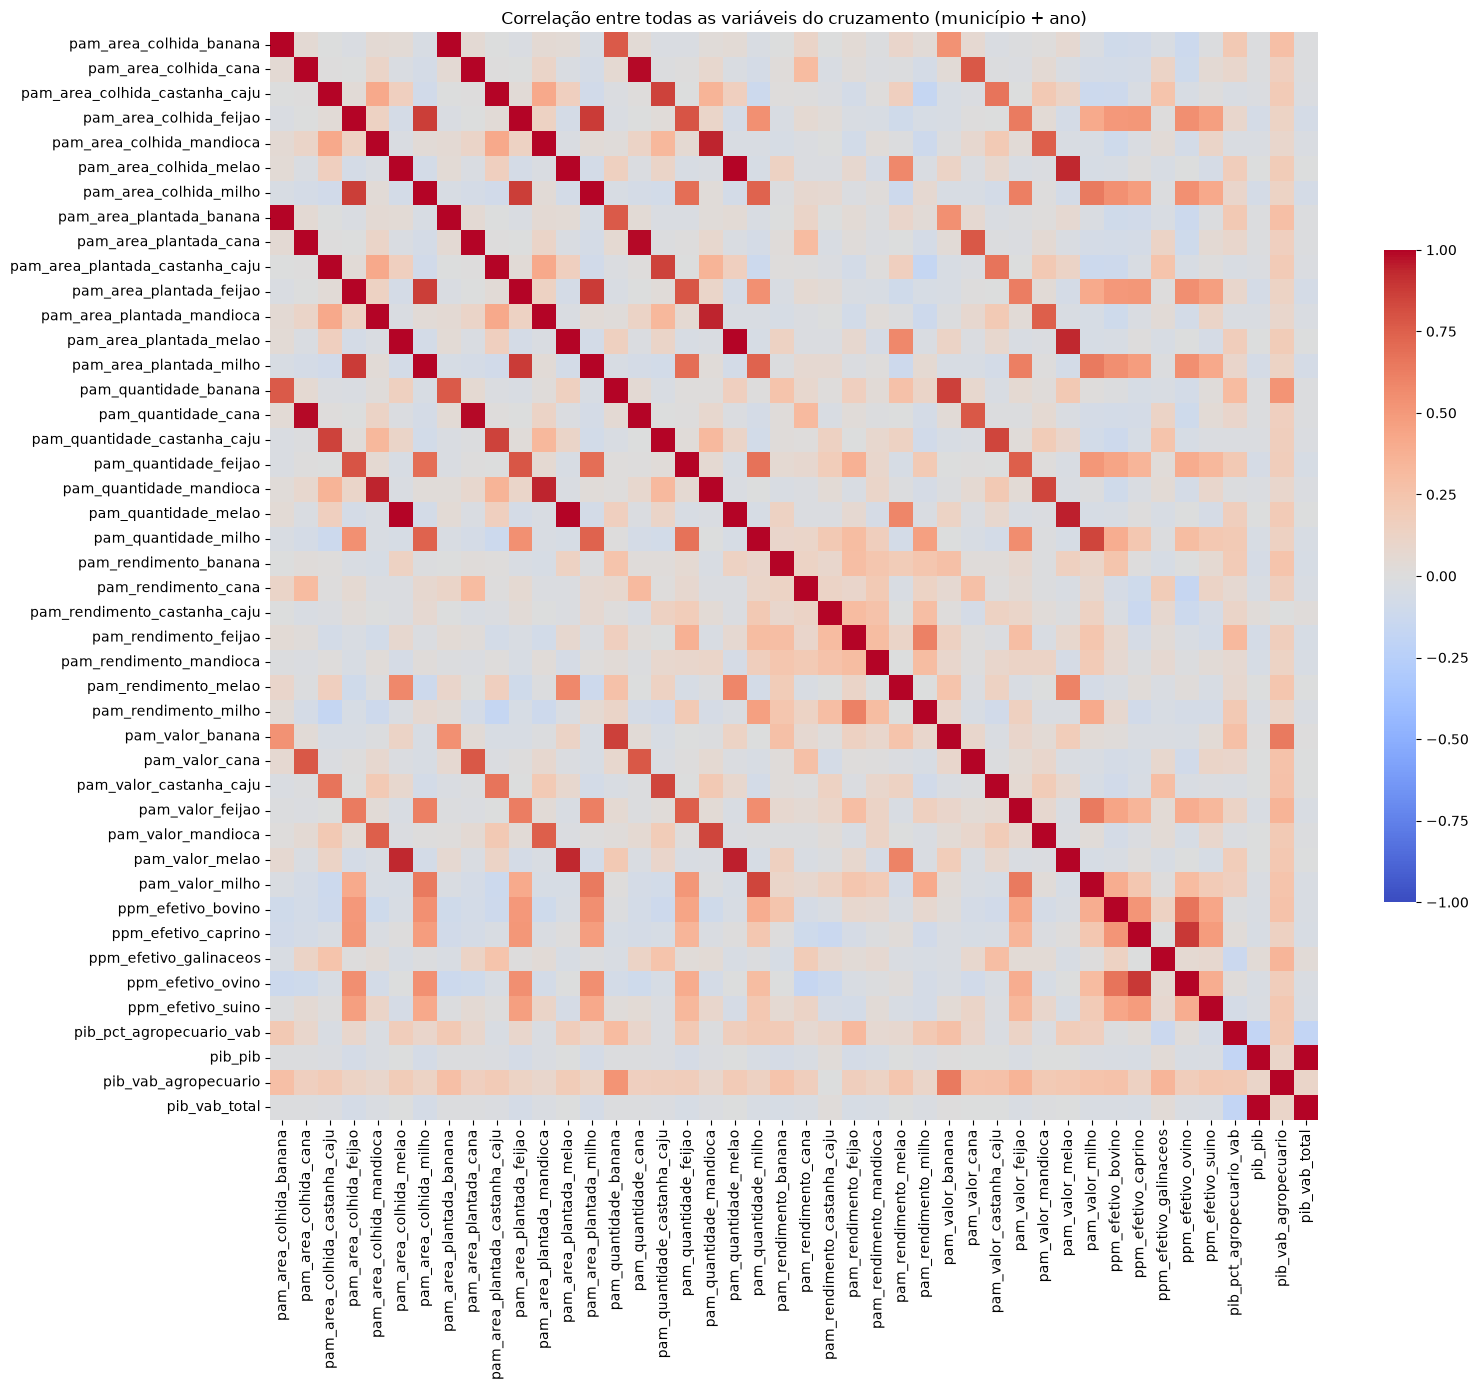

In [6]:
colunas_valor = [c for c in df_nome.columns if c not in ('territorio_codigo', 'territorio_nome', 'ano_nome')]
correlacao_geral = df_nome[colunas_valor].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sb.heatmap(correlacao_geral, cmap='coolwarm', vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('Correlação entre todas as variáveis do cruzamento (município + ano)')
plt.tight_layout()
plt.show()

Quais são as correlações mais fortes *entre bases diferentes* (não dentro da mesma base)?

In [7]:
pares_cruzados = []
for i, a in enumerate(colunas_valor):
    for b in colunas_valor[i + 1:]:
        base_a, base_b = a.split('_')[0], b.split('_')[0]
        if base_a != base_b:
            v = correlacao_geral.loc[a, b]
            if pd.notna(v):
                pares_cruzados.append((v, a, b))

pares_cruzados.sort(key=lambda x: abs(x[0]), reverse=True)

print("Top 15 correlações entre bases diferentes:")
for v, a, b in pares_cruzados[:15]:
    print(f"{v:+.2f}  {a}  x  {b}")

Top 15 correlações entre bases diferentes:
+0.64  pam_valor_banana  x  pib_vab_agropecuario
+0.55  pam_area_colhida_feijao  x  ppm_efetivo_ovino
+0.55  pam_area_plantada_feijao  x  ppm_efetivo_ovino
+0.55  pam_area_plantada_milho  x  ppm_efetivo_ovino
+0.55  pam_area_plantada_milho  x  ppm_efetivo_bovino
+0.55  pam_area_colhida_milho  x  ppm_efetivo_ovino
+0.54  pam_area_colhida_milho  x  ppm_efetivo_bovino
+0.53  pam_quantidade_banana  x  pib_vab_agropecuario
+0.51  pam_area_colhida_feijao  x  ppm_efetivo_caprino
+0.51  pam_area_plantada_feijao  x  ppm_efetivo_caprino
+0.50  pam_area_plantada_feijao  x  ppm_efetivo_bovino
+0.50  pam_area_colhida_feijao  x  ppm_efetivo_bovino
+0.48  pam_area_colhida_milho  x  ppm_efetivo_caprino
+0.48  pam_area_plantada_milho  x  ppm_efetivo_caprino
+0.48  pam_area_colhida_feijao  x  ppm_efetivo_suino


**Leitura:** a correlação mais forte entre PAM e PIB é `pam_valor_banana` x `pib_vab_agropecuario` (+0.64) — municípios com mais valor de produção de banana tendem a ter VAB agropecuário maior, o que faz sentido (banana puxa a base econômica agrícola local). Já entre PAM e PPM, área plantada/colhida de milho e feijão correlaciona com efetivo de bovino, ovino e caprino (~0.5) — indício de que são os mesmos municípios de agricultura familiar mista (grãos + criação de pequenos animais), não que uma coisa cause a outra.

Como essas correlações mais fortes parecem quando a gente olha o espalhamento real dos pontos, não só o número?

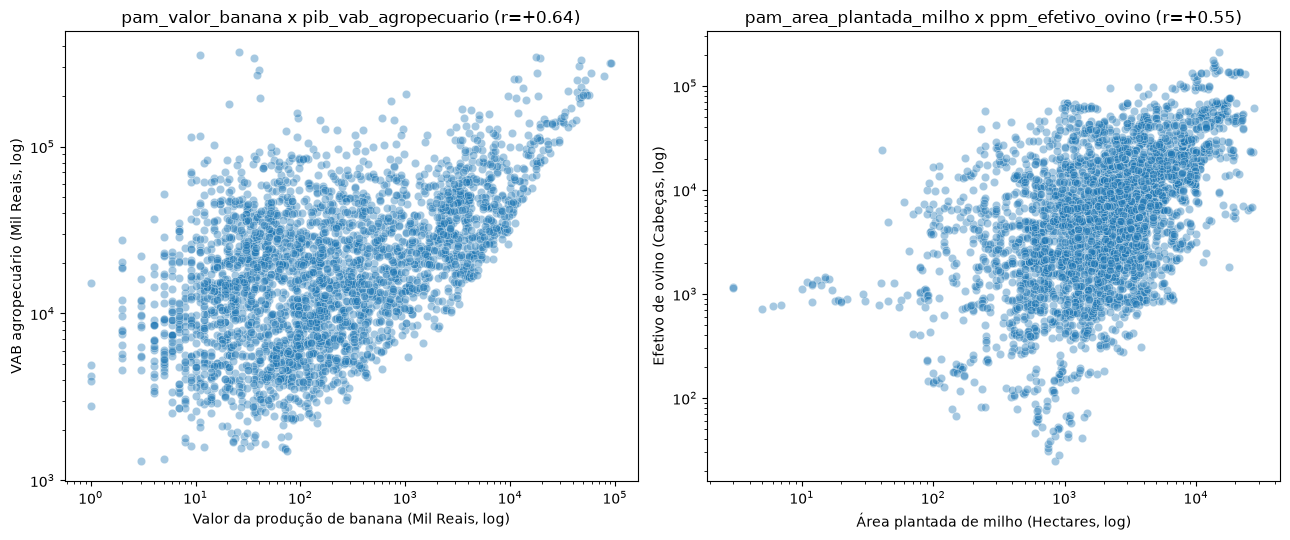

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sb.scatterplot(data=df_nome, x='pam_valor_banana', y='pib_vab_agropecuario', alpha=0.4, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('pam_valor_banana x pib_vab_agropecuario (r=+0.64)')
axes[0].set_xlabel('Valor da produção de banana (Mil Reais, log)')
axes[0].set_ylabel('VAB agropecuário (Mil Reais, log)')

sb.scatterplot(data=df_nome, x='pam_area_plantada_milho', y='ppm_efetivo_ovino', alpha=0.4, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('pam_area_plantada_milho x ppm_efetivo_ovino (r=+0.55)')
axes[1].set_xlabel('Área plantada de milho (Hectares, log)')
axes[1].set_ylabel('Efetivo de ovino (Cabeças, log)')

plt.tight_layout()
plt.show()

Essa correlação entre valor de banana e VAB agropecuário é estável ao longo dos anos, ou só aparece quando junta tudo de uma vez?

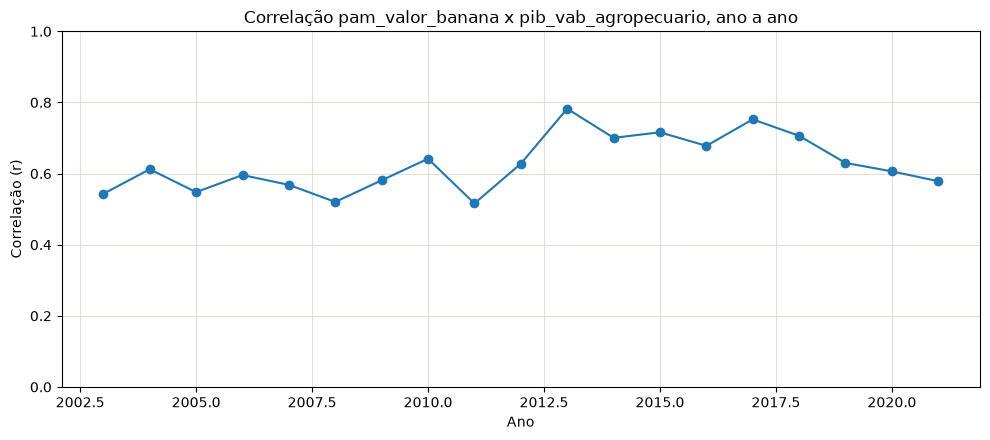

2003    0.54
2004    0.61
2005    0.55
2006    0.60
2007    0.57
2008    0.52
2009    0.58
2010    0.64
2011    0.52
2012    0.63
2013    0.78
2014    0.70
2015    0.72
2016    0.68
2017    0.75
2018    0.71
2019    0.63
2020    0.61
2021    0.58
dtype: float64


In [9]:
correlacao_por_ano = {}
for ano_i in sorted(df_nome['ano_nome'].unique()):
    sub = df_nome[df_nome['ano_nome'] == ano_i]
    if sub['pib_vab_agropecuario'].notna().sum() > 5:
        correlacao_por_ano[ano_i] = sub['pam_valor_banana'].corr(sub['pib_vab_agropecuario'])

correlacao_por_ano = pd.Series(correlacao_por_ano)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(correlacao_por_ano.index, correlacao_por_ano.values, marker='o')
ax.set_ylim(0, 1)
ax.set_xlabel('Ano')
ax.set_ylabel('Correlação (r)')
ax.set_title('Correlação pam_valor_banana x pib_vab_agropecuario, ano a ano')
ax.grid(True, color='#e1e0d9', linewidth=0.8)
plt.tight_layout()
plt.show()

print(correlacao_por_ano.round(2))

**Leitura:** a correlação fica sempre entre +0,52 e +0,78, sem nenhum ano em que ela suma ou vire negativa — é uma relação estável ao longo dos 19 anos com dado de VAB agropecuário, não um efeito de misturar tudo junto.

### PAM (valor da produção) x PIB

Olhando só o valor da produção agrícola contra as métricas do PIB, o que aparece?

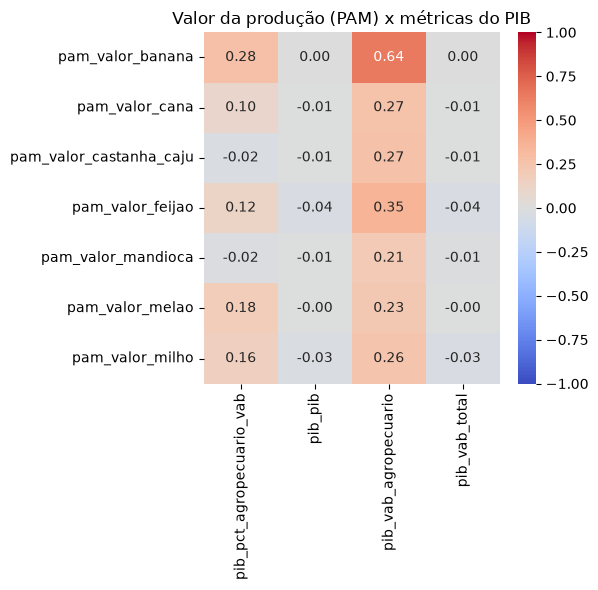

In [10]:
colunas_pam_valor = [c for c in colunas_valor if c.startswith('pam_valor_')]
colunas_pib = [c for c in colunas_valor if c.startswith('pib_')]

sub_corr = df_nome[colunas_pam_valor + colunas_pib].corr().loc[colunas_pam_valor, colunas_pib]

fig, ax = plt.subplots(figsize=(6, 6))
sb.heatmap(sub_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Valor da produção (PAM) x métricas do PIB')
plt.tight_layout()
plt.show()

### PAM (área) x PPM (efetivo)

E entre área plantada/colhida dos 7 produtos e o efetivo das 5 espécies?

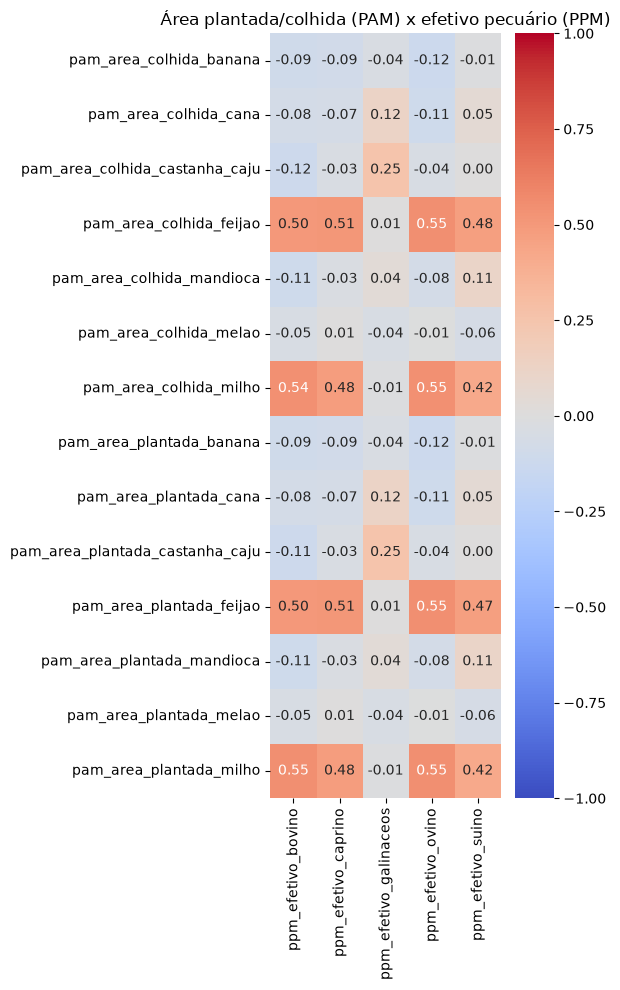

In [11]:
colunas_pam_area = [c for c in colunas_valor if 'area' in c]
colunas_ppm = [c for c in colunas_valor if c.startswith('ppm_')]

sub_corr2 = df_nome[colunas_pam_area + colunas_ppm].corr().loc[colunas_pam_area, colunas_ppm]

fig, ax = plt.subplots(figsize=(6, 10))
sb.heatmap(sub_corr2, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Área plantada/colhida (PAM) x efetivo pecuário (PPM)')
plt.tight_layout()
plt.show()

## Estudo de caso: São Gonçalo do Amarante

Quanto o PIB de São Gonçalo do Amarante realmente cresceu entre 2003 e 2023, e isso aparece também na agropecuária do município?

In [12]:
sga = df_nome[df_nome['territorio_nome'] == 'São Gonçalo do Amarante - CE'].set_index('ano_nome')

fator_pib_sga = sga.loc[2023, 'pib_pib'] / sga.loc[2003, 'pib_pib']
print(f"PIB São Gonçalo do Amarante — 2003: {sga.loc[2003, 'pib_pib']:,.0f} mil reais")
print(f"PIB São Gonçalo do Amarante — 2023: {sga.loc[2023, 'pib_pib']:,.0f} mil reais")
print(f"Fator de crescimento: {fator_pib_sga:.1f}x")

PIB São Gonçalo do Amarante — 2003: 98,728 mil reais
PIB São Gonçalo do Amarante — 2023: 6,908,373 mil reais
Fator de crescimento: 70.0x


Esse crescimento também aparece nas colunas do PAM e do PPM, ou só no PIB?

In [13]:
crescimento_sga = (sga.loc[2023, colunas_valor] / sga.loc[2003, colunas_valor]).replace([np.inf, -np.inf], np.nan).dropna()
crescimento_sga = crescimento_sga[sga.loc[2003, colunas_valor] > 0].sort_values(ascending=False)

print("Fator de crescimento 2003 -> 2023, São Gonçalo do Amarante, por coluna:")
for coluna, fator in crescimento_sga.items():
    print(f"{coluna}: {fator:.2f}x")

Fator de crescimento 2003 -> 2023, São Gonçalo do Amarante, por coluna:
pib_pib: 69.97x
pam_valor_banana: 8.82x
pam_valor_mandioca: 3.11x
ppm_efetivo_suino: 2.80x
pam_valor_milho: 2.65x
pam_valor_feijao: 1.68x
pam_rendimento_mandioca: 1.62x
ppm_efetivo_galinaceos: 1.60x
pam_rendimento_milho: 1.29x
pam_area_plantada_banana: 1.25x
pam_area_colhida_banana: 1.25x
pam_quantidade_banana: 1.08x
pam_rendimento_banana: 0.87x
pam_rendimento_cana: 0.86x
pam_rendimento_castanha_caju: 0.82x
pam_rendimento_feijao: 0.76x
ppm_efetivo_bovino: 0.69x
ppm_efetivo_ovino: 0.69x
pam_quantidade_milho: 0.65x
ppm_efetivo_caprino: 0.61x
pam_area_plantada_milho: 0.50x
pam_area_colhida_milho: 0.50x
pam_valor_castanha_caju: 0.45x
pam_quantidade_mandioca: 0.45x
pam_area_colhida_feijao: 0.44x
pam_area_plantada_feijao: 0.44x
pam_quantidade_feijao: 0.34x
pam_area_colhida_mandioca: 0.28x
pam_area_plantada_mandioca: 0.28x
pam_area_colhida_castanha_caju: 0.20x
pam_area_plantada_castanha_caju: 0.20x
pam_quantidade_castanha

/tmp/ipykernel_73258/1603745240.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  crescimento_sga = (sga.loc[2023, colunas_valor] / sga.loc[2003, colunas_valor]).replace([np.inf, -np.inf], np.nan).dropna()


**Leitura:** o PIB de São Gonçalo do Amarante cresceu **~70x** entre 2003 e 2023 — de fato o maior crescimento de PIB entre os 184 municípios do Ceará (não 500x, mas ainda assim o topo do ranking estadual). O que chama atenção é que **nenhuma coluna de PAM ou PPM acompanha esse salto**: efetivo de bovino, caprino e ovino caíram no período (0,6x–0,7x), área colhida de quase todos os produtos também caiu, e só suíno (2,8x) e galináceos (1,6x) cresceram — bem abaixo dos 70x do PIB. Ou seja, o crescimento econômico de São Gonçalo do Amarante **não é agropecuário**: é coerente com a industrialização do Complexo Industrial e Portuário do Pecém, que fica no município, e não com nenhuma das bases agrícolas ou pecuárias analisadas aqui. Para contexto, o maior crescimento do cruzamento inteiro nem é de PIB: é **311,8x** no valor da produção de mandioca em Várzea Alegre (PAM).

## Estudo de caso: Várzea Alegre (maior crescimento do cruzamento inteiro)

311,8x em valor de mandioca é um dado real ou um artefato de base muito pequena em 2003?

In [14]:
va = df_nome[df_nome['territorio_nome'] == 'Várzea Alegre - CE'].set_index('ano_nome')
print(va[['pam_valor_mandioca', 'pam_quantidade_mandioca', 'pam_area_plantada_mandioca']].loc[[2003, 2004, 2005, 2015, 2020, 2021, 2022, 2023]])

          pam_valor_mandioca  pam_quantidade_mandioca  pam_area_plantada_mandioca
ano_nome                                                                         
2003                     4.0                     20.0                         2.0
2004                     4.0                     24.0                         2.0
2005                     6.0                     36.0                         3.0
2015                    60.0                     40.0                         5.0
2020                   560.0                    350.0                        20.0
2021                   380.0                    253.0                        25.0
2022                  1124.0                    525.0                        25.0
2023                  1247.0                    494.0                        26.0


**Leitura:** o dado é real, mas o crescimento "de 311,8x" é enganoso — em 2003 Várzea Alegre produzia mandioca em apenas 2 hectares, gerando 4 mil reais (base quase zero). O salto pra 1.247 mil reais em 2023 é grande em termos absolutos, mas o fator multiplicativo explode justamente porque o denominador (2003) era minúsculo. Isso é um lembrete geral: **fator de crescimento em municípios pequenos deve sempre vir acompanhado do valor absoluto**, senão qualquer salto de "quase nada" para "pouco" parece um recorde.

## Índice: valor agrícola / VAB agropecuário

Em quais municípios o valor bruto da produção agrícola (todos os 7 produtos, mesma unidade Mil Reais) mais pesa em relação ao VAB agropecuário declarado no PIB, no último ano com os dois dados (2021)?

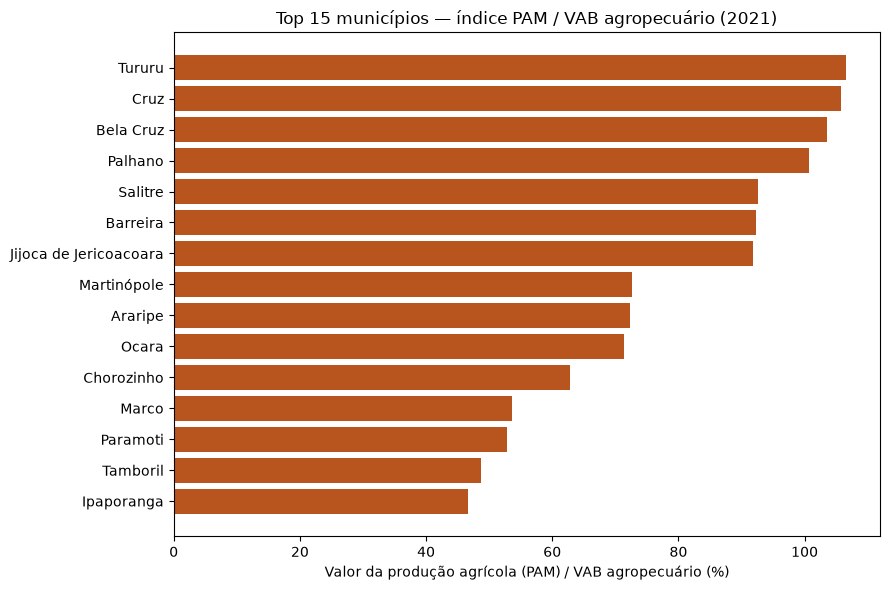

       territorio_nome  pam_valor_total  pib_vab_agropecuario  indice_pam_vab
                Tururu          18411.0               17268.0      106.619180
                  Cruz          28180.0               26657.0      105.713321
             Bela Cruz          67981.0               65661.0      103.533300
               Palhano          17920.0               17809.0      100.623280
               Salitre          23342.0               25194.0       92.649043
              Barreira          32331.0               35044.0       92.258304
Jijoca de Jericoacoara           8338.0                9075.0       91.878788
           Martinópole           5404.0                7437.0       72.663708
               Araripe          26316.0               36361.0       72.374247
                 Ocara          34907.0               48855.0       71.450210
            Chorozinho          11422.0               18176.0       62.841109
                 Marco          13610.0               25369.0   

In [15]:
ano_indice = 2021
dados_indice = df_nome[df_nome['ano_nome'] == ano_indice].copy()
dados_indice['pam_valor_total'] = dados_indice[colunas_pam_valor].sum(axis=1)
dados_indice = dados_indice.dropna(subset=['pib_vab_agropecuario'])
dados_indice = dados_indice[(dados_indice['pam_valor_total'] > 0) & (dados_indice['pib_vab_agropecuario'] > 0)]
dados_indice['indice_pam_vab'] = dados_indice['pam_valor_total'] / dados_indice['pib_vab_agropecuario'] * 100

top15_indice = dados_indice.sort_values('indice_pam_vab', ascending=False).head(15).copy()
top15_indice['territorio_nome'] = top15_indice['territorio_nome'].str.replace(' - CE', '', regex=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15_indice['territorio_nome'], top15_indice['indice_pam_vab'], color='#b8551f')
ax.invert_yaxis()
ax.set_xlabel('Valor da produção agrícola (PAM) / VAB agropecuário (%)')
ax.set_title(f'Top 15 municípios — índice PAM / VAB agropecuário ({ano_indice})')
plt.tight_layout()
plt.show()

print(top15_indice[['territorio_nome', 'pam_valor_total', 'pib_vab_agropecuario', 'indice_pam_vab']].to_string(index=False))

**Leitura:** índice exploratório, não oficial — valores acima de 100% indicam que o valor bruto da produção agrícola (PAM) sozinho supera o VAB agropecuário declarado no PIB, algo plausível em municípios pequenos e muito concentrados em poucos produtos. Não implica causalidade nem substitui o VAB como medida de estrutura econômica; é a mesma leitura já usada no dashboard, aqui replicada no notebook.